In [421]:
from histpy import Histogram, HealpixAxis, Axis, Axes
from mhealpy import HealpixMap
from astropy.coordinates import SkyCoord, cartesian_to_spherical, Galactic

from cosipy.response import FullDetectorResponse, PointSourceResponse, GalacticResponse
# from cosipy.spacecraftfile import SpacecraftFile
# from cosipy.ts_map.TSMap import TSMap
from cosipy.data_io import UnBinnedData, BinnedData
from cosipy.image_deconvolution import SpacecraftAttitudeExposureTable, CoordsysConversionMatrix, DataIF_COSI_DC2, ImageDeconvolution
from cosipy.ts_map import FastNormFit, FastTSMap
from cosipy.util import fetch_wasabi_file

# cosipy uses astropy units
import astropy.units as u
from astropy.units import Quantity
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.table import Table
from astropy.io import fits
from scoords import Attitude, SpacecraftFrame

#3ML is needed for spectral modeling
from threeML import *
from astromodels import Band
import h5py

#Other standard libraries
import os
import glob
from pathlib import Path
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib import cycler
from matplotlib.gridspec import GridSpec 

import healpy as hp
from tqdm.autonotebook import tqdm

# Matplotlib style template
## For black, set #000000. For navy, set #002060
defaultcolor = '#002060'
plt.rcParams.update({'text.color': defaultcolor, 'axes.labelcolor': defaultcolor, 
                     'xtick.color': defaultcolor, 'ytick.color': defaultcolor,
                     'axes.prop_cycle': cycler(color=['b', 'r', 'limegreen']),
                     'font.family':'serif', 'font.serif': 'Times New Roman',
                     'font.size': 22, 'lines.linewidth': 3,
                     'figure.figsize': (9.6, 5.4), 'figure.dpi': 100})

#### Preprocessing

In [ ]:
# hist = Histogram.open('../../DC3/data/responses/extended_source_response_Fe60_low_merged.h5')

# new_axes = []

# axis = hist.axes[0]
# new_axes += [HealpixAxis(edges=np.array(axis),
#                          nside=axis.nside,
#                          label=axis.label,
#                          scheme=axis.scheme,
#                          coordsys=axis.coordsys)]

# for axis in hist.axes[1:3]:
#     new_axes += [Axis(np.array([1154, 1160]) * u.keV,
#                     label = axis.label,
#                     scale = axis.axis_scale)]

# axis = hist.axes[3]
# new_axes += [Axis(axis.edges, label = axis.label,
#                   scale = axis.axis_scale)]

# axis = hist.axes[4]
# new_axes += [HealpixAxis(edges=np.array(axis),
#                          nside=axis.nside,
#                          label=axis.label,
#                          scheme=axis.scheme,
#                          coordsys=axis.coordsys)]

In [ ]:
# new_hist = Histogram(new_axes,
#                            contents=hist.contents,
#                            sparse=hist.is_sparse,
#                            unit=hist.unit)

# new_hist.write('psr.h5')

In [ ]:
# # Load all 14 weeks of data
# filenames = sorted(glob.glob('../data/*.fits'))
# data_obj.get_binned_data(filenames[0])

# for filename in filenames[1:]:
#     data_loader_obj.get_binned_data(filename)
#     data_obj.binned_data = data_obj.binned_data + data_loader_obj.binned_data

fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimensi

In [ ]:
# data_obj.binned_data.write('44Ti_binned_data.hdf5')

### Data Loading

In [422]:
# psr = GalacticResponse.open('psr.h5')
# psr = Histogram.open('psr.h5')
psr = Histogram.open('../data/responses/extended_source_response_Ti44_merged.h5')

In [423]:
# Create binned data object for sources
data_obj = BinnedData("inputs.yaml")
data_loader_obj = BinnedData("inputs.yaml")

# Create binned data object for background
bg_obj = BinnedData("inputs.yaml")

In [432]:
data_obj.load_binned_data_from_hdf5('44Ti_binned_data.hdf5')
bg_obj.load_binned_data_from_hdf5('../data/backgrounds/binned/gal_DC4_bkg_Ti44_binned_smoothed_fwhm_10.0deg.hdf5')

In [433]:
data = data_obj.binned_data     # Need all 3 months data to use with pre-computed response and background
bg = bg_obj.binned_data

## Image Deconvolution

In [426]:
data_interface = DataIF_COSI_DC2.load(name = "44Ti_MAP",
                                      event_binned_data = data.project(['Em', 'Phi', 'PsiChi']),
                                      dict_bkg_binned_data = {"total": bg.project(['Em', 'Phi', 'PsiChi'])},
                                      rsp = psr,
                                      coordsys_conv_matrix=None,
                                    #   is_miniDC2_format=False
                                      )

In [427]:
config_filename = 'MAPdeconvolution.yml'

# create image deconvolution and run
image_deconvolution = ImageDeconvolution()
image_deconvolution.set_dataset([data_interface])
image_deconvolution.read_parameterfile(config_filename)
image_deconvolution.initialize()
image_deconvolution.run_deconvolution()

image_deconvolution.results[-3:]

A directory ./results_MAP already exists. Files in ./results_MAP may be overwritten. Make sure that is not a problem.


  0%|          | 0/50 [00:00<?, ?it/s]

[{'iteration': 48,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x46dfe31c0>,
  'prior_filter': <histpy.histogram.Histogram at 0x46dcd3c40>,
  'background_normalization': {'total': <Quantity 1.04756647>},
  'log-likelihood': [<Quantity -121606.09195697>],
  'log-prior': {'gamma_model': <Quantity 874.4410867>,
   'gamma_bkg': <Quantity 0.>},
  'log-posterior': -120731.65087027322},
 {'iteration': 49,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x46df08820>,
  'prior_filter': <histpy.histogram.Histogram at 0x46dcfdcc0>,
  'background_normalization': {'total': <Quantity 1.04758867>},
  'log-likelihood': [<Quantity -121606.00782649>],
  'log-prior': {'gamma_model': <Quantity 902.67903064>,
   'gamma_bkg': <Quantity 0.>},
  'log-posterior': -120703.32879584732},
 {'iteration': 50,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x46dcd25f0>,
  'prior_filter': <histpy.histogram.Histogram at 0x46dcfc400>,
  'backgroun

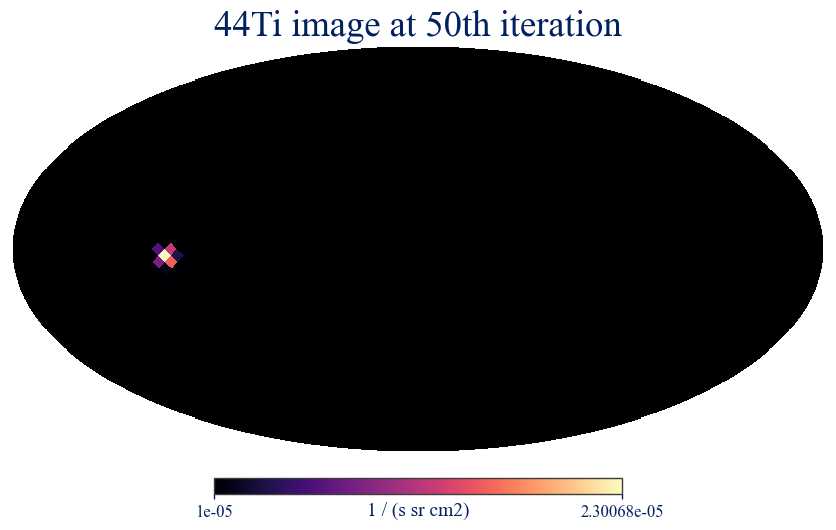

In [428]:
iteration_idx = 49

result = image_deconvolution.results[iteration_idx]

iteration = result['iteration']
image = result['model']

data = image[:,0]
data[data <= 0 * data.unit] = 1e-12 * data.unit

hp.mollview(data, min = 1e-5, norm ='log', unit = str(data.unit), title = f'44Ti image at {iteration}th iteration', cmap = 'magma')

plt.show()

In [131]:
def plot_reconstructed_image(result, source_position = None): # source_position should be (l,b) in degrees
    iteration = result['iteration']
    image = result['model']

    for energy_index in range(image.axes['Ei'].nbins):
        map_healpxmap = HealpixMap(data = image[:,energy_index], unit = image.unit)

        _, ax = map_healpxmap.plot('mollview')        
        
        _.colorbar.set_label(str(image.unit))
        
        if source_position is not None:
            ax.scatter(source_position[0]*u.deg, source_position[1]*u.deg, transform=ax.get_transform('world'), color = 'red')

        plt.title(label = f"iteration = {iteration}, energy_index = {energy_index} ({image.axes['Ei'].bounds[energy_index][0]}-{image.axes['Ei'].bounds[energy_index][1]})")
        plt.show()

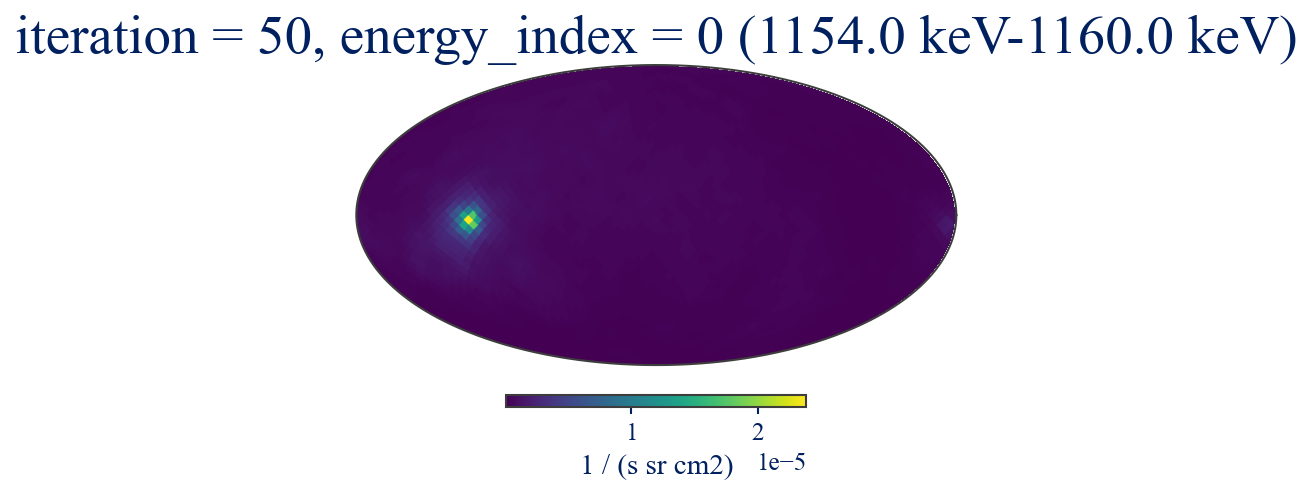

In [132]:
iteration = 49

plot_reconstructed_image(image_deconvolution.results[iteration])

## TS Map

In [478]:
F = 1e-6 * u.ph / u.cm / u.cm / u.s
mu = 1173.2 * u.keV
sigma = 5 * u.keV

spectrum = Gaussian()
spectrum.F.value = F.value
spectrum.F.unit = F.unit
spectrum.mu.value = mu.value 
spectrum.mu.unit = mu.unit
spectrum.sigma.value = sigma.value
spectrum.sigma.unit = sigma.unit

In [479]:
ts = FastTSMap(
               data = data.project('Em', 'Phi', 'PsiChi'), 
               bkg_model = bg.project('Em', 'Phi', 'PsiChi'), 
               orientation = None, 
               response_path = 'psr.h5',
               cds_frame = "galactic",
               )

112.8183819802457
1359


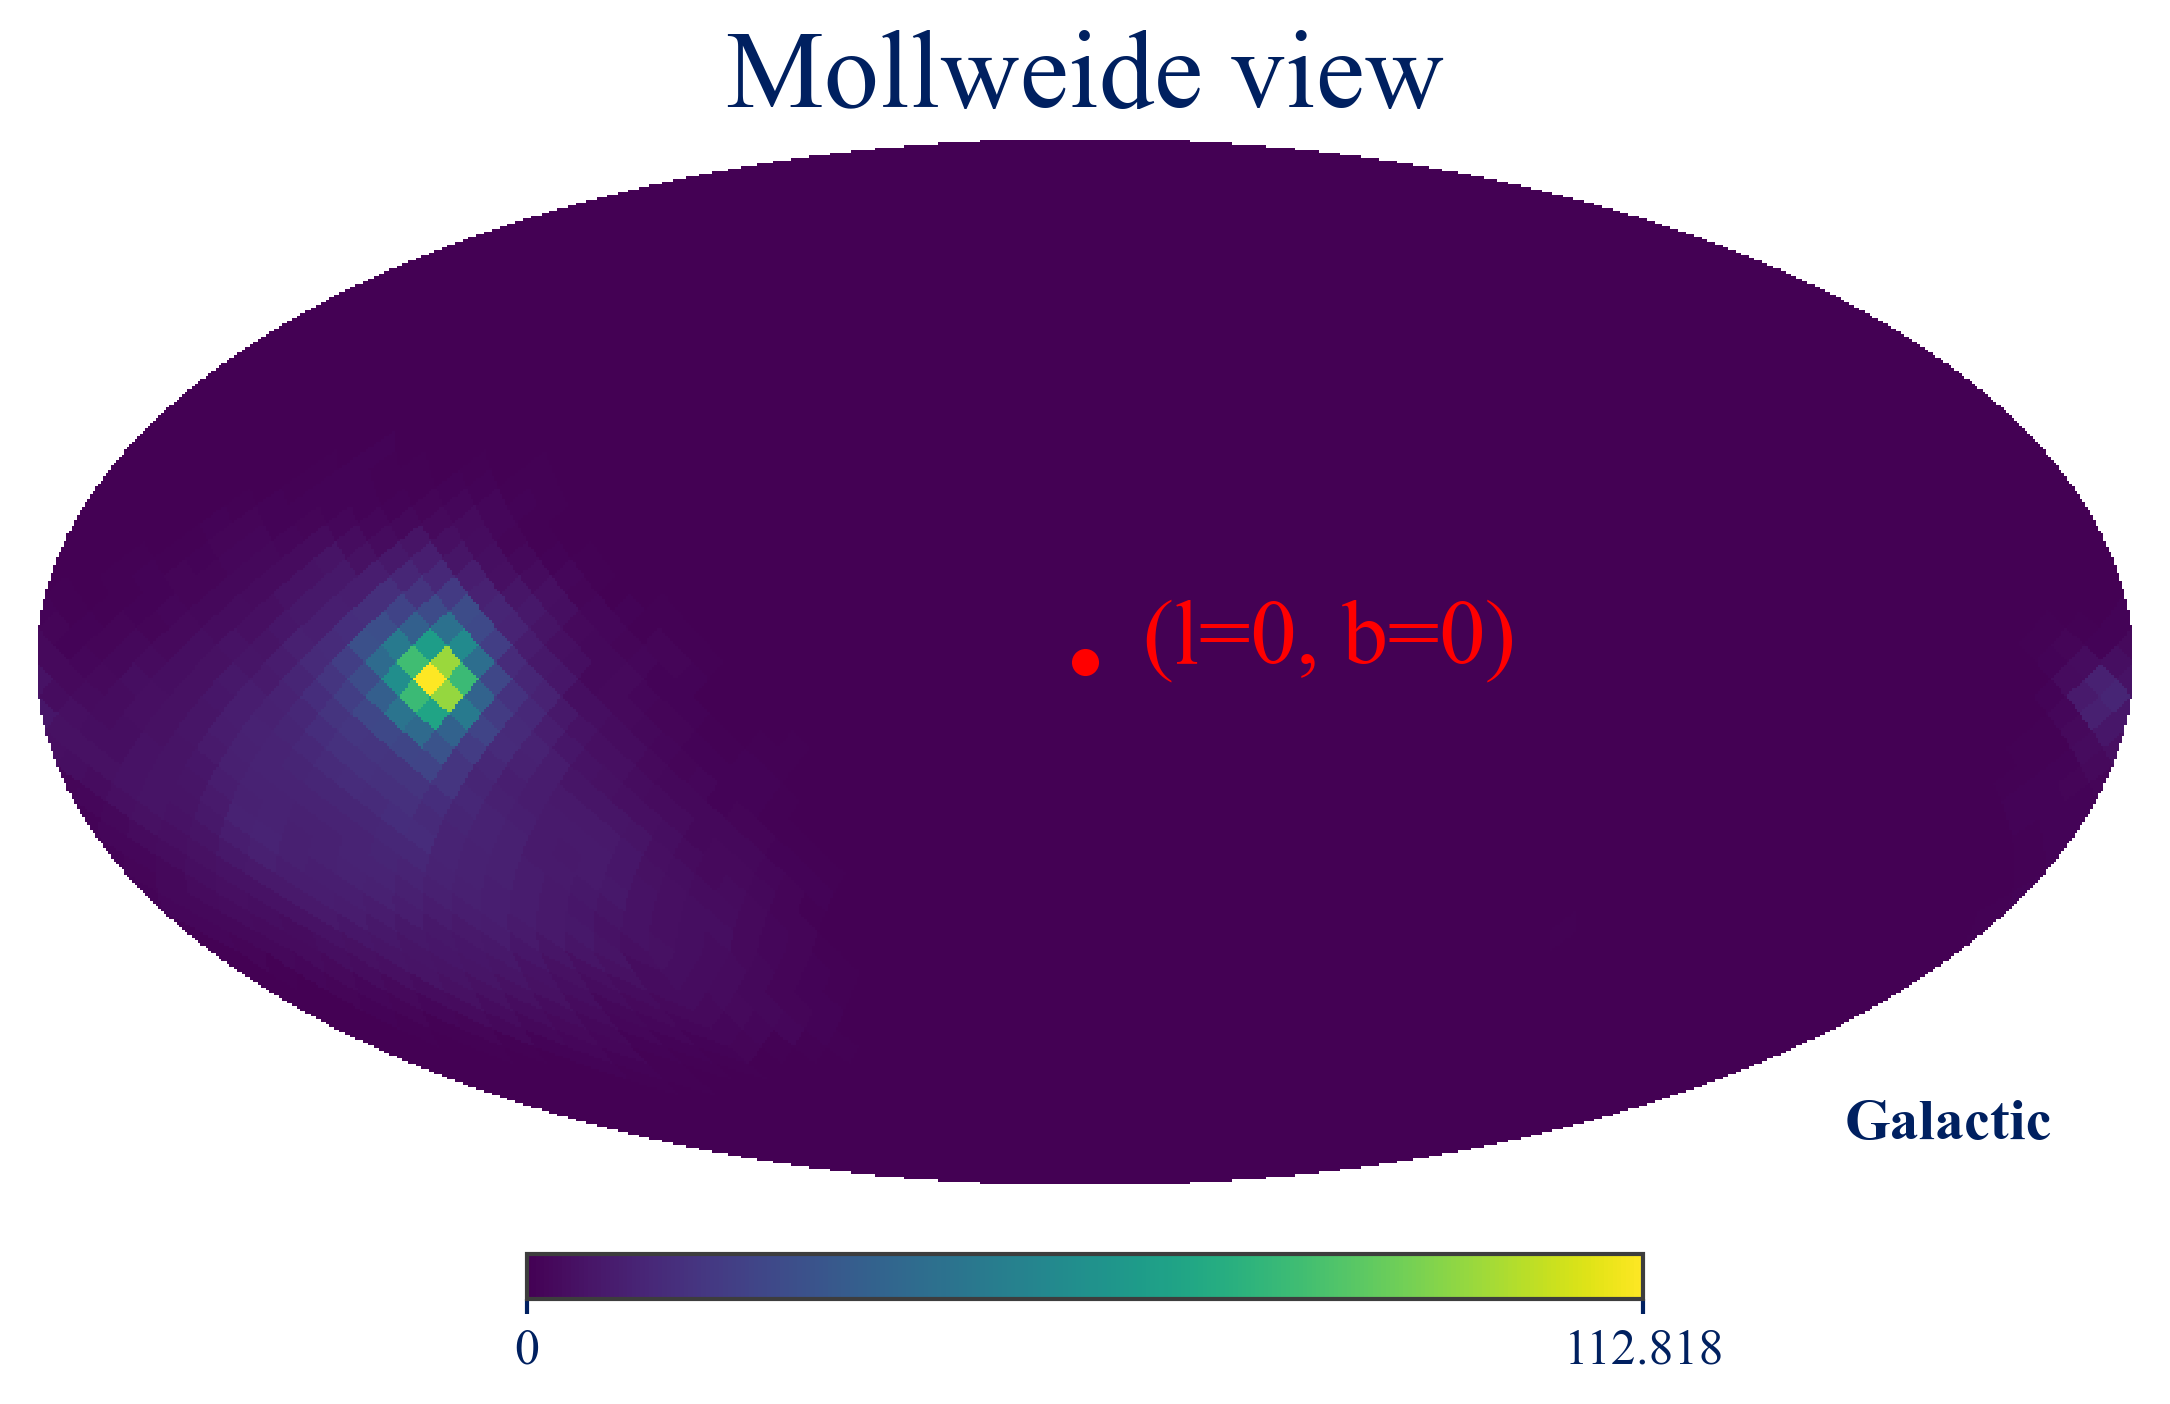

In [480]:
ts_results = ts.fit(nside = 16, spectrum = spectrum, cpu_cores=1, energy_channel=[0, 1])
print(ts_results.max())

hp_idx = np.argmax(ts_results)
print(hp_idx)

ts.plot_ts(ts_results, skycoord = None, containment = None, scheme="nested",
            save_plot = False, dpi = 300)

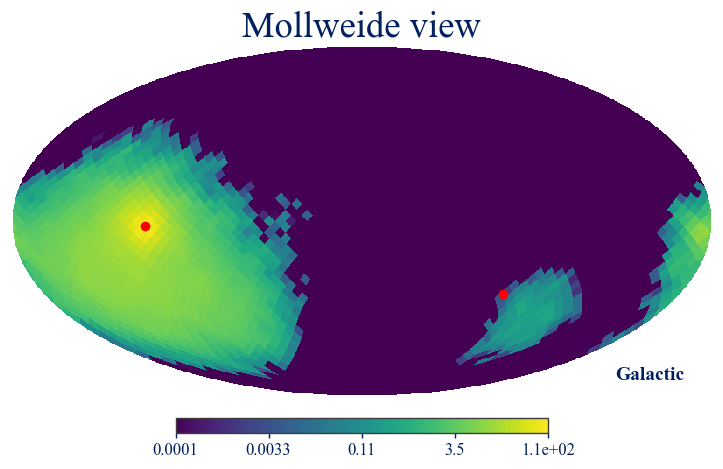

In [481]:
hp.mollview(ts_results+0.0001, nest=True, coord = "G", hold = True, norm='log')
hp.projscatter(279.7, -31.2, marker = "o", lonlat=True, coord = "G", color = "red")
hp.projscatter(111.7, -2.1, marker = "o", lonlat=True, coord = "G", color = "red")
cbar = plt.gcf().axes[1]
cbar.set_xticks(np.geomspace(cbar.get_xlim()[0], cbar.get_xlim()[1], 5))
cbar.set_xticklabels([f'{x:.2g}' for x in np.geomspace(cbar.get_xlim()[0], cbar.get_xlim()[1], 5)])
plt.show()

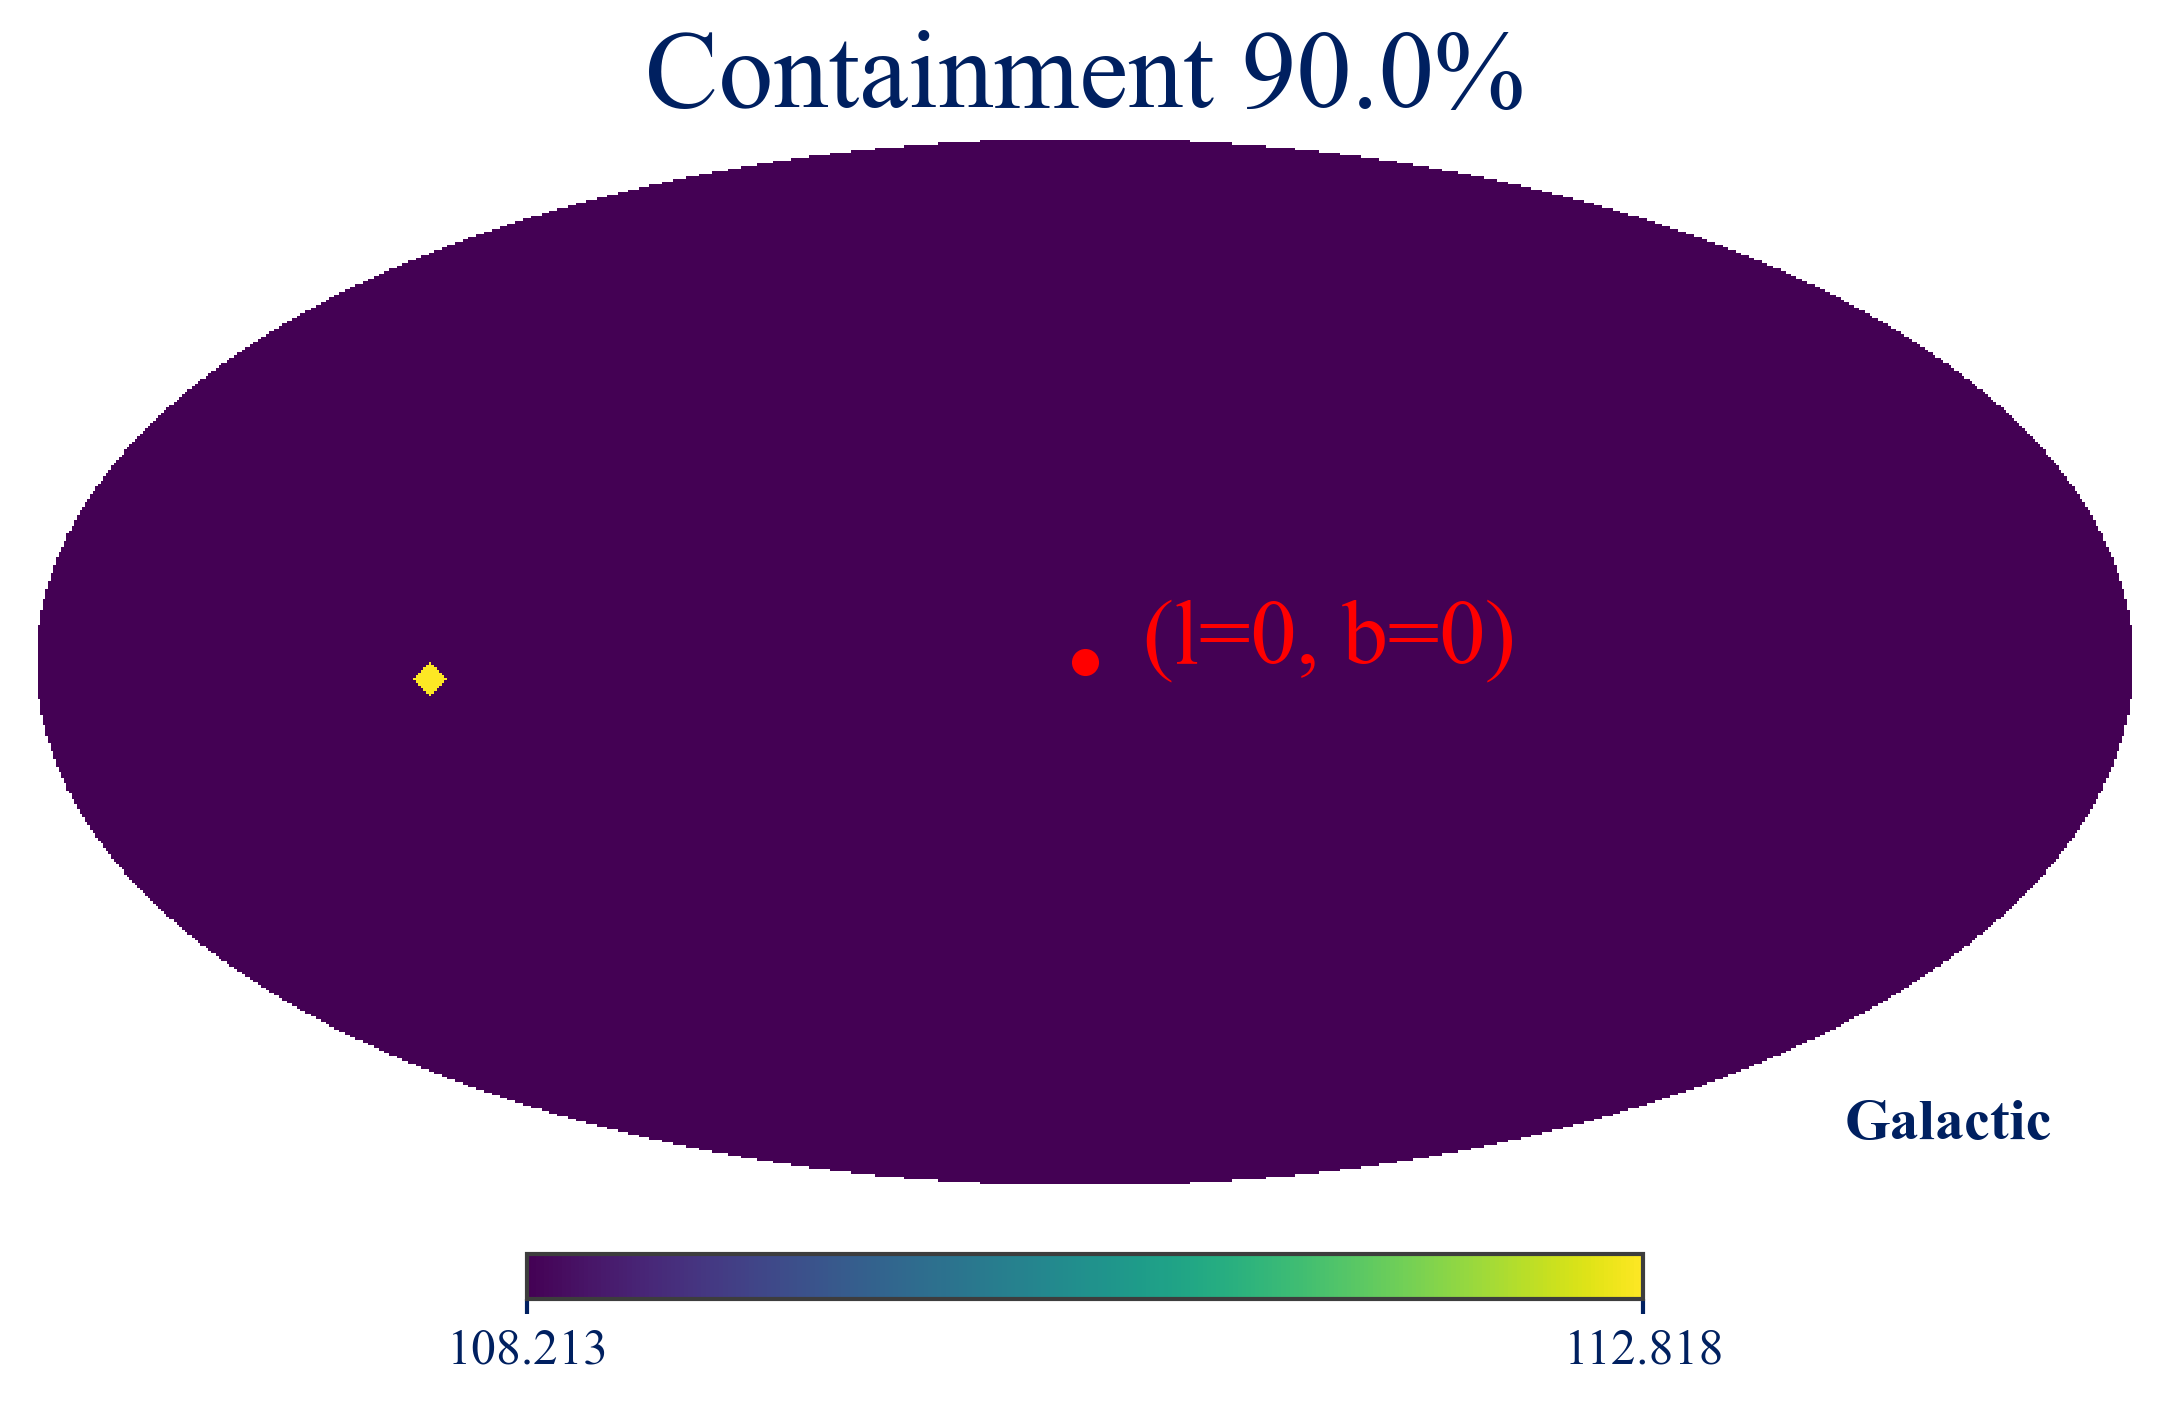

In [220]:
ts.plot_ts(ts_results, containment = 0.9)

## Crab and Cas A as background

In [449]:
# Crab
crab = BinnedData('inputs.yaml')
crab.get_binned_data(unbinned_data = '../../DC3/Crab/sources/crab_standard_3months_unbinned_data_filtered_with_SAAcut.fits')

# Cas A
casa = BinnedData('inputs.yaml')
casa.get_binned_data(unbinned_data = 'sources/CasAG16distribution_3months_unbinned_data_filtered_with_SAAcut.fits')

# Alternately, use source injector to create template models
# Use the same pre-computed response file with a fairly representative
# flux. For a narrow 1154-1160 keV energy bin, the exact spectral 
# shape wouldn't matter (i.e., wouldn't impart any biases in the Phi,
# PsiChi axes)

fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking


In [450]:
ts = FastTSMap(
               data = data.project('Em', 'Phi', 'PsiChi'), 
               bkg_model = bg.project('Em', 'Phi', 'PsiChi') + \
                           crab.binned_data.project('Em', 'Phi', 'PsiChi') + \
                           casa.binned_data.project('Em', 'Phi', 'PsiChi'),
               orientation = None, 
               response_path = 'psr.h5',
               cds_frame = "galactic",
               )

1.5289087062358817
2516


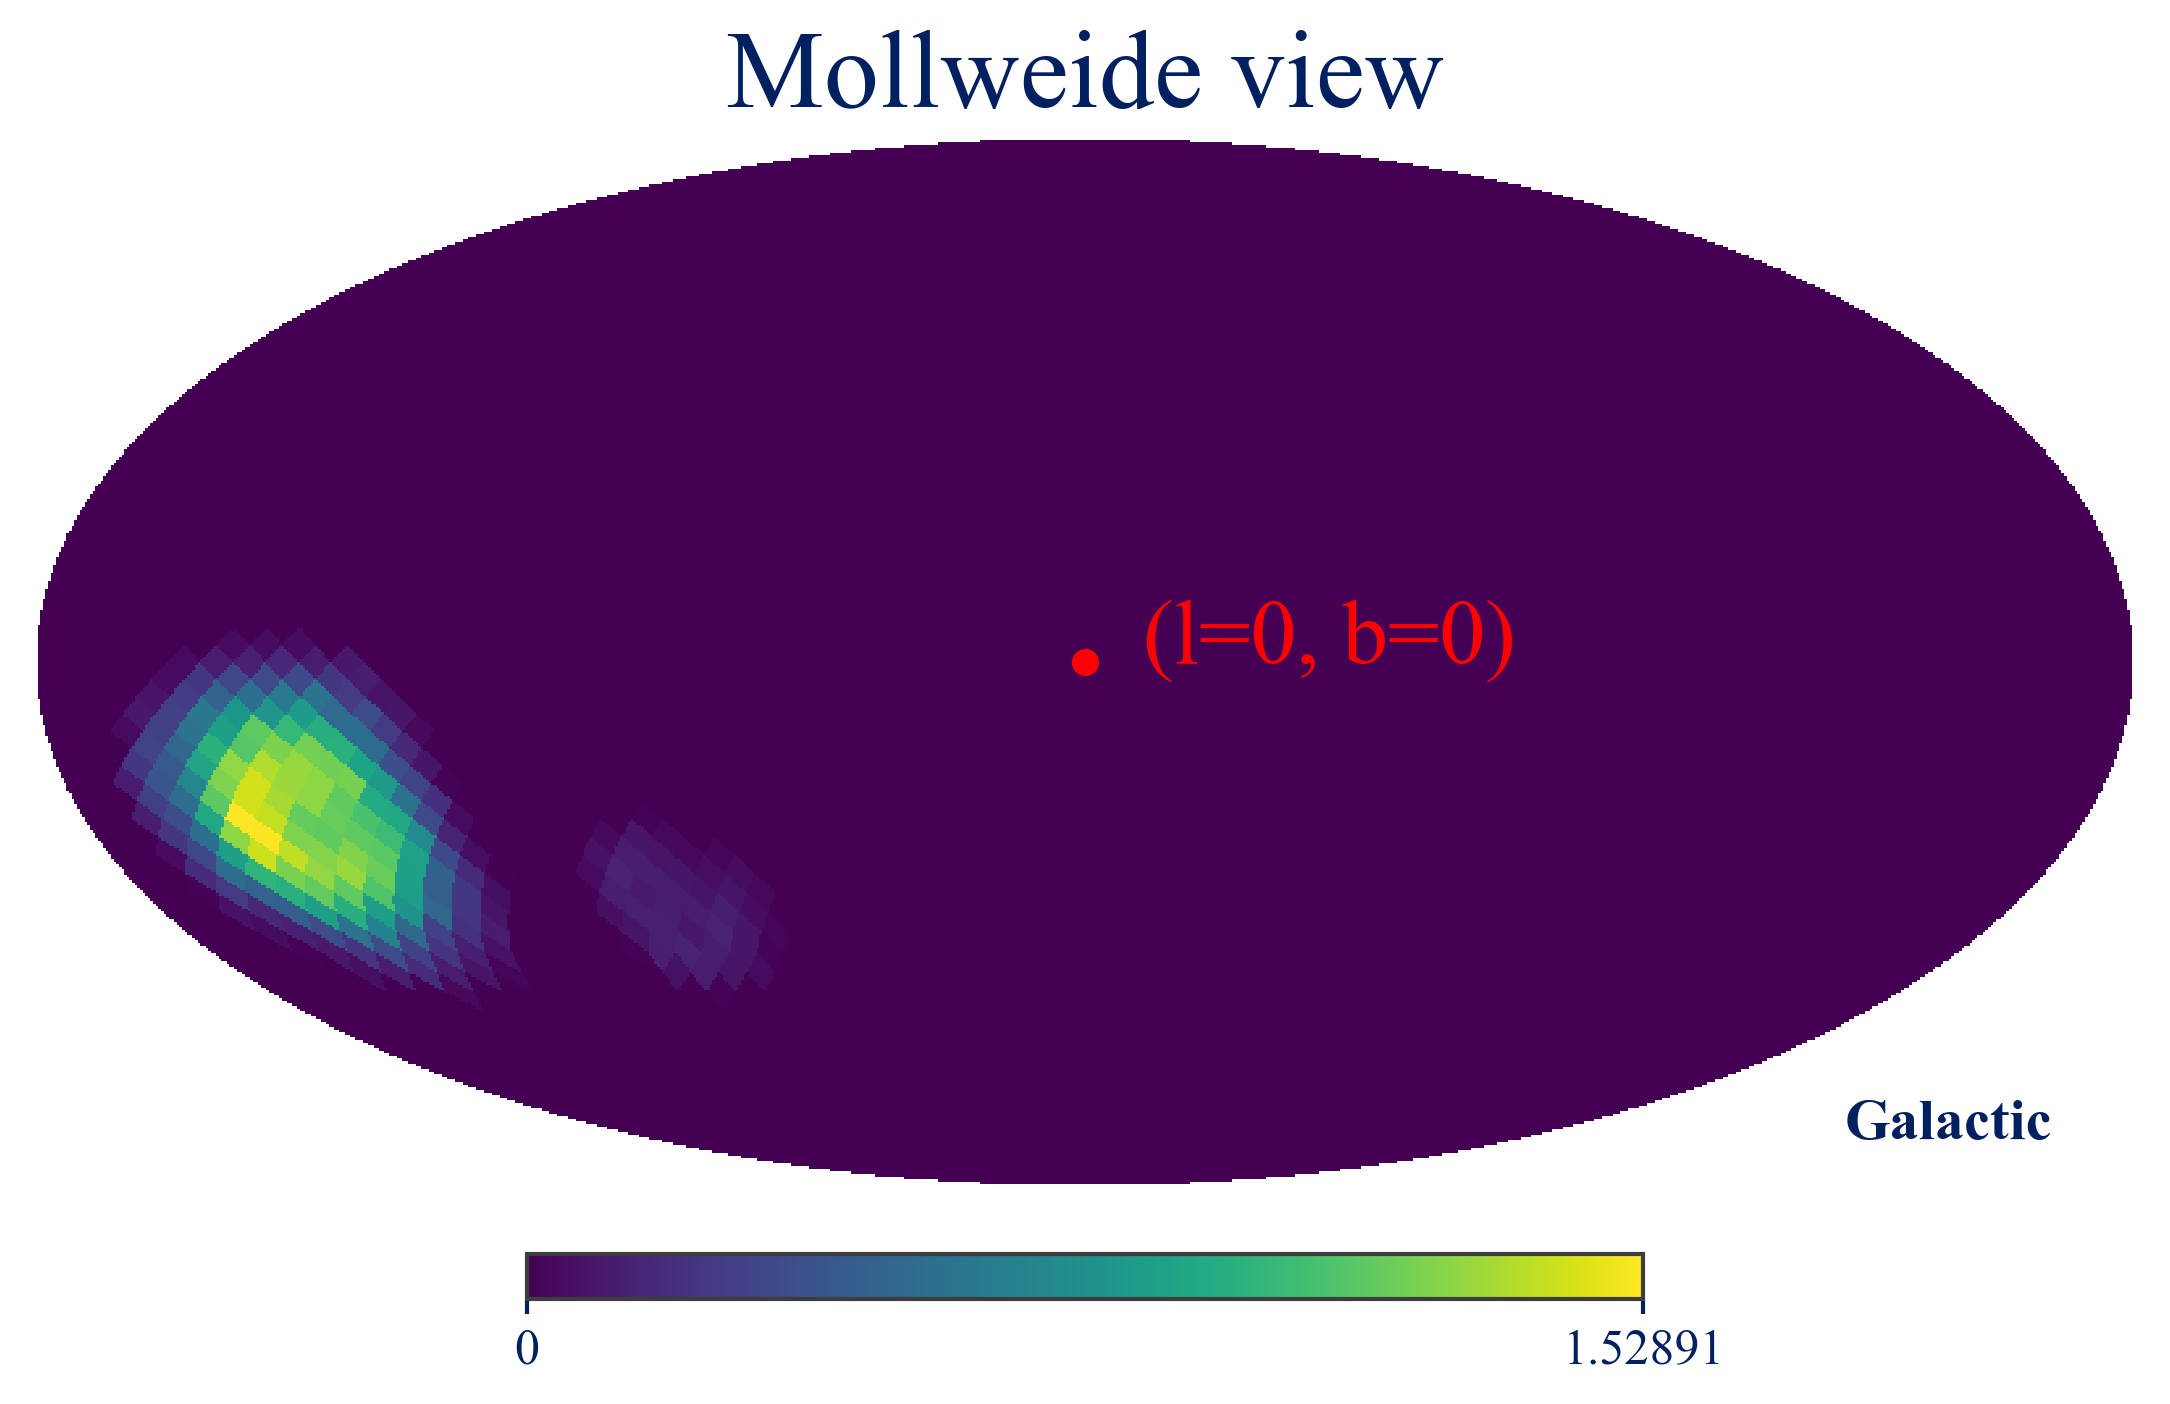

In [451]:
ts_results = ts.fit(nside = 16, spectrum = spectrum, cpu_cores=1, energy_channel=[0, 1])
print(ts_results.max())

hp_idx = np.argmax(ts_results)
print(hp_idx)

ts.plot_ts(ts_results, skycoord = None, containment = None, scheme="nested",
            save_plot = False, dpi = 300)

In [51]:
hp.pix2ang(16, 2516, nest=True, lonlat=True)

(151.875, -22.02431283704216)

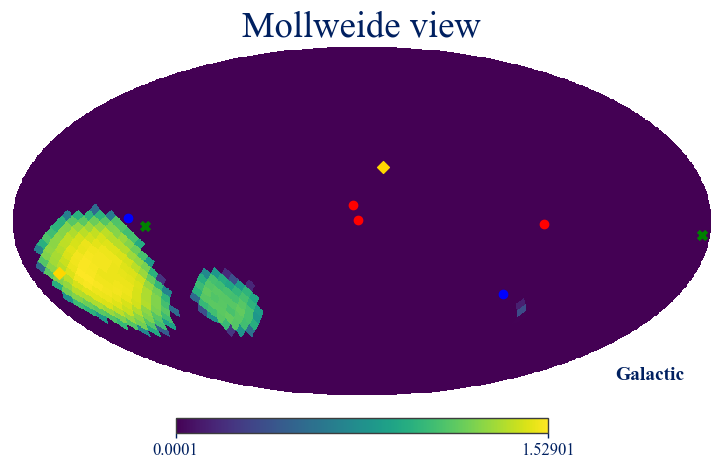

In [457]:
hp.mollview(ts_results+0.0001, nest=True, coord = "G", hold = True, norm='log')
hp.projscatter(111.7, -2.1, marker = "x", lonlat=True, coord = "G", color = "g")
hp.projscatter(184.56, -5.78, marker = "x", lonlat=True, coord = "G", color = "g")
hp.projscatter(279.7, -31.2, marker = "o", lonlat=True, coord = "G", color = "blue")
hp.projscatter(120.1,  1.4, marker = "o", lonlat=True, coord = "G", color = "blue")
hp.projscatter(266.3, -1.21, marker = "o", lonlat=True, coord = "G", color = "red")
hp.projscatter(4.5, 6.8, marker = "o", lonlat=True, coord = "G", color = "red")
hp.projscatter(1.9, 0.3, marker = "o", lonlat=True, coord = "G", color = "red")
hp.projscatter(163, -22, marker = "D", lonlat=True, coord = "G", color = "gold")
hp.projscatter(348.5, 22.5, marker = "D", lonlat=True, coord = "G", color = "gold")
plt.show()

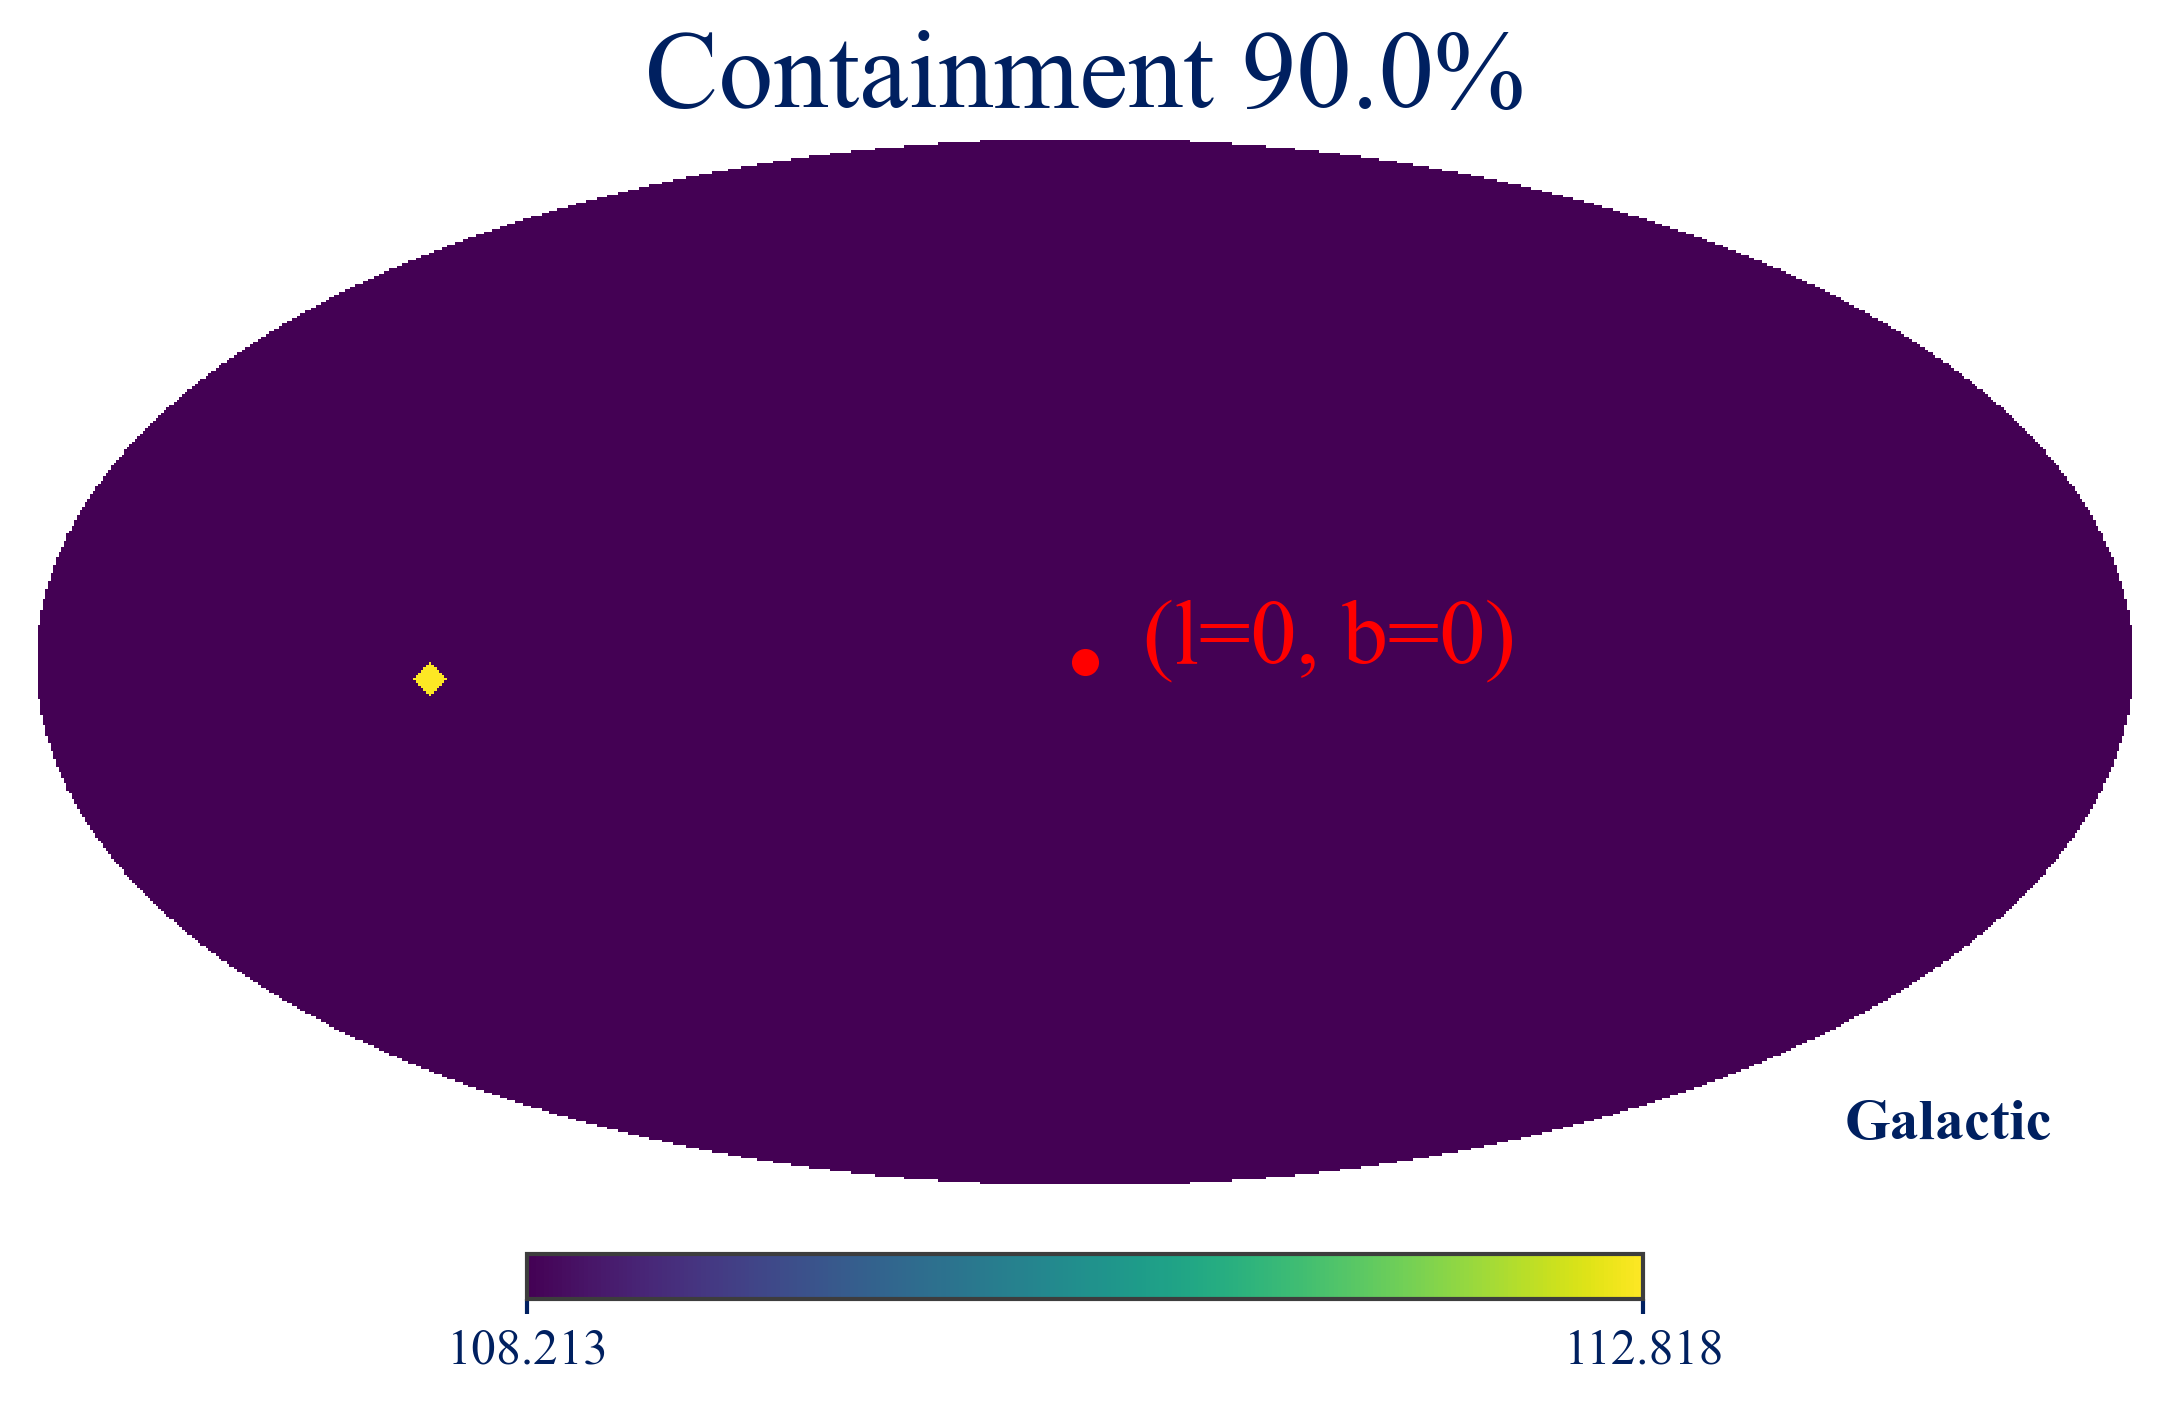

In [ ]:
ts.plot_ts(ts_results, containment = 0.9)

### Image Deconvolution

In [270]:
data_interface = DataIF_COSI_DC2.load(name = "44Ti_MAP",
                                      event_binned_data = data.project(['Em', 'Phi', 'PsiChi']),
                                      dict_bkg_binned_data = {"total": bg.project(['Em', 'Phi', 'PsiChi']),
                                                              'crab': crab.binned_data.project(['Em', 'Phi', 'PsiChi']),
                                                              'casa': casa.binned_data.project(['Em', 'Phi', 'PsiChi'])},
                                      rsp = psr,
                                      coordsys_conv_matrix=None
                                      )

In [ ]:
config_filename = 'MAPdeconvolution.yml'

# create image deconvolution and run
image_deconvolution = ImageDeconvolution()
image_deconvolution.set_dataset([data_interface])
image_deconvolution.read_parameterfile(config_filename)
image_deconvolution.initialize()
image_deconvolution.run_deconvolution()

image_deconvolution.results[-3:]

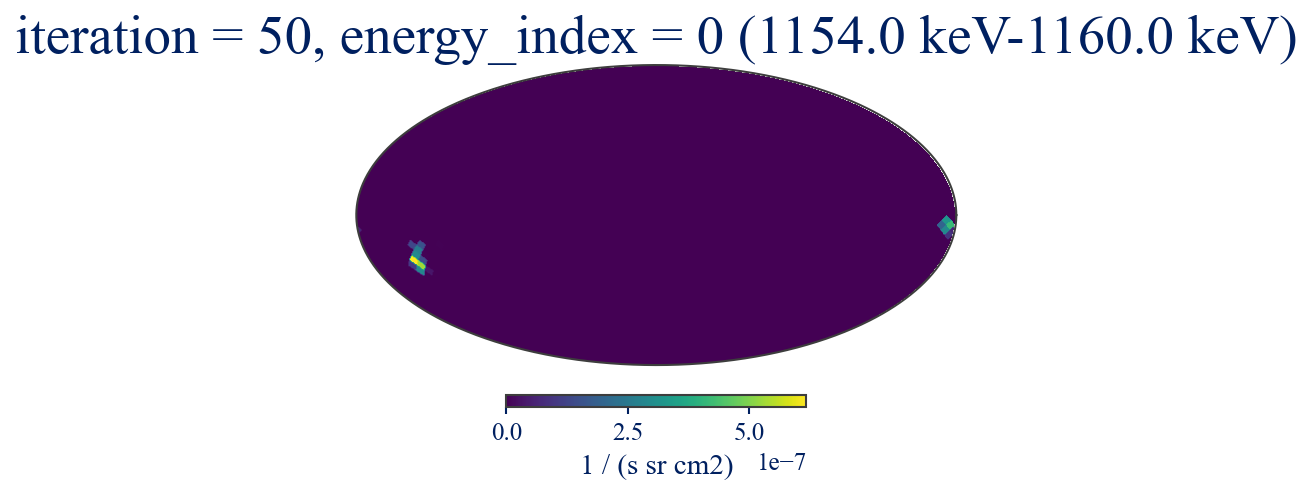

In [288]:
iteration = 49

plot_reconstructed_image(image_deconvolution.results[iteration])

## Applying poisson fluctuations to background

### Image Deconvolution

In [342]:
baby = bg.project(['Em', 'Phi', 'PsiChi']).todense().contents
np.random.poisson(baby.flatten()[np.where(baby.flatten() > 5)[0]])

array([4, 7, 3, 6, 9, 5, 4, 8, 3, 4, 4, 2, 3, 5, 1, 8, 7])

In [367]:
l = []
for i in range(5000):
    l.append(np.random.poisson(baby).sum() - baby.sum())

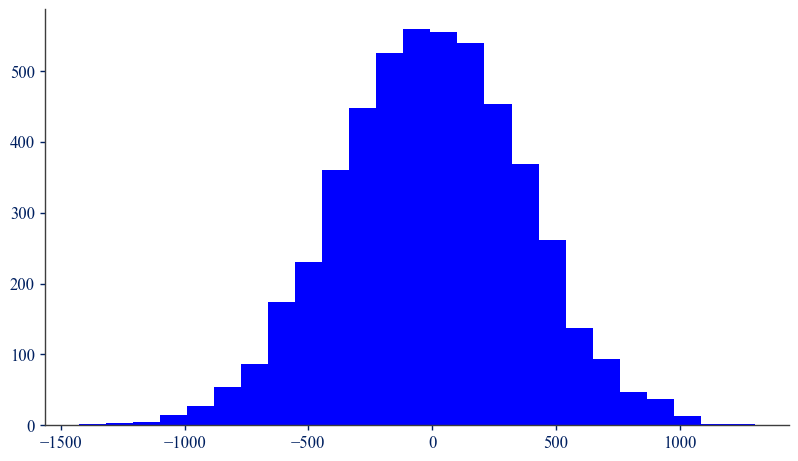

In [368]:
plt.hist(l)
plt.show()

In [397]:
hist = bg.project(['Em', 'Phi', 'PsiChi']).todense()

new_axes = []

for axis in hist.axes[:2]:
    new_axes += [Axis(axis.edges, label = axis.label,
                    scale = axis.axis_scale)]

axis = hist.axes[2]
new_axes += [HealpixAxis(edges=np.array(axis),
                         nside=axis.nside,
                         label=axis.label,
                         scheme=axis.scheme,
                         coordsys=axis.coordsys)]

new_bg = Histogram(new_axes,
                           contents = np.random.poisson(hist.contents),
                           sparse=hist.is_sparse,
                           unit=hist.unit)

In [ ]:
# new_bg = deepcopy(bg)
# new_bg = np.random.poisson(bg.project(['Em', 'Phi', 'PsiChi']).todense().contents)

In [402]:
data_interface = DataIF_COSI_DC2.load(name = "44Ti_MAP",
                                      event_binned_data = data.project(['Em', 'Phi', 'PsiChi']),
                                      dict_bkg_binned_data = {"total": new_bg,},
                                                            #   'crab': crab.binned_data.project(['Em', 'Phi', 'PsiChi']),
                                                            #   'casa': casa.binned_data.project(['Em', 'Phi', 'PsiChi'])},
                                      rsp = psr,
                                      coordsys_conv_matrix=None
                                      )

In [409]:
config_filename = 'MAPdeconvolution.yml'

# create image deconvolution and run
image_deconvolution = ImageDeconvolution()
image_deconvolution.set_dataset([data_interface])
image_deconvolution.read_parameterfile(config_filename)
image_deconvolution.initialize()
image_deconvolution.run_deconvolution()

image_deconvolution.results[-3:]

A directory ./results_MAP already exists. Files in ./results_MAP may be overwritten. Make sure that is not a problem.


  0%|          | 0/50 [00:00<?, ?it/s]

[{'iteration': 48,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x46db2d420>,
  'prior_filter': <histpy.histogram.Histogram at 0x46db6c070>,
  'background_normalization': {'total': <Quantity 0.28243381>},
  'log-likelihood': [<Quantity -145325.97805393>],
  'log-prior': {'gamma_model': <Quantity 263.59091804>,
   'gamma_bkg': <Quantity 0.>},
  'log-posterior': -145062.38713589482},
 {'iteration': 49,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x46db2ef80>,
  'prior_filter': <histpy.histogram.Histogram at 0x46db564a0>,
  'background_normalization': {'total': <Quantity 0.28242294>},
  'log-likelihood': [<Quantity -145324.21586437>],
  'log-prior': {'gamma_model': <Quantity 263.61157438>,
   'gamma_bkg': <Quantity 0.>},
  'log-posterior': -145060.60428998465},
 {'iteration': 50,
  'model': <cosipy.image_deconvolution.allskyimage.AllSkyImageModel at 0x46db2e7d0>,
  'prior_filter': <histpy.histogram.Histogram at 0x46db57040>,
  'backgrou

**WHY IS THE BACKGROUND NORMALIZATION ALWAYS FALLING TO 0.28 FROM 1.04**

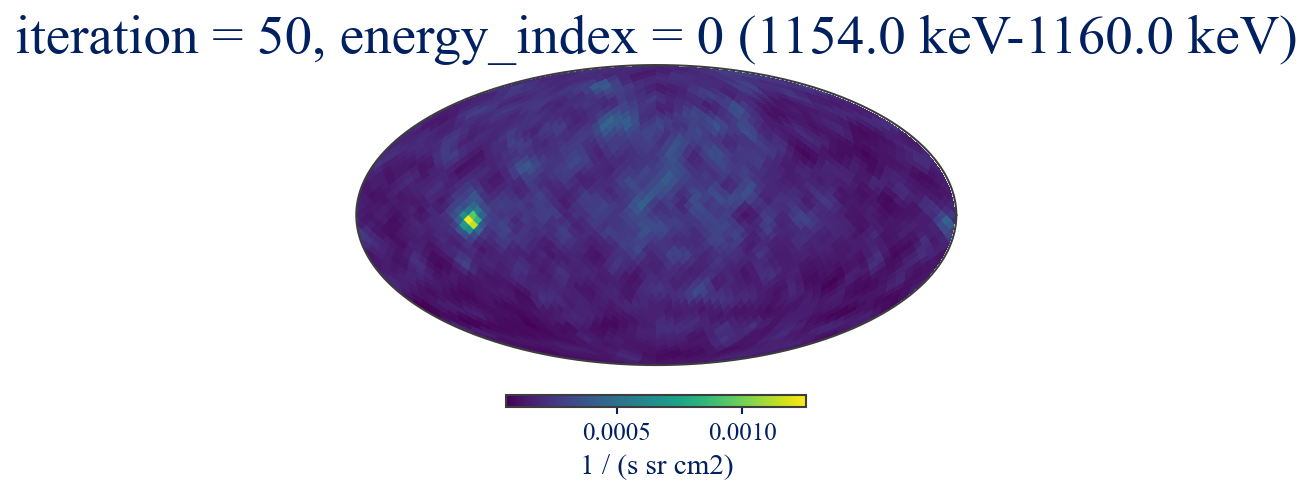

In [410]:
iteration = 49

plot_reconstructed_image(image_deconvolution.results[iteration])

### TS Map

In [415]:
ts = FastTSMap(
               data = data.project('Em', 'Phi', 'PsiChi'), 
               bkg_model = new_bg,# + \
                        #    crab.binned_data.project('Em', 'Phi', 'PsiChi') + \
                        #    casa.binned_data.project('Em', 'Phi', 'PsiChi'),
               orientation = None, 
               response_path = 'psr.h5',
               cds_frame = "galactic",
               )

0
0


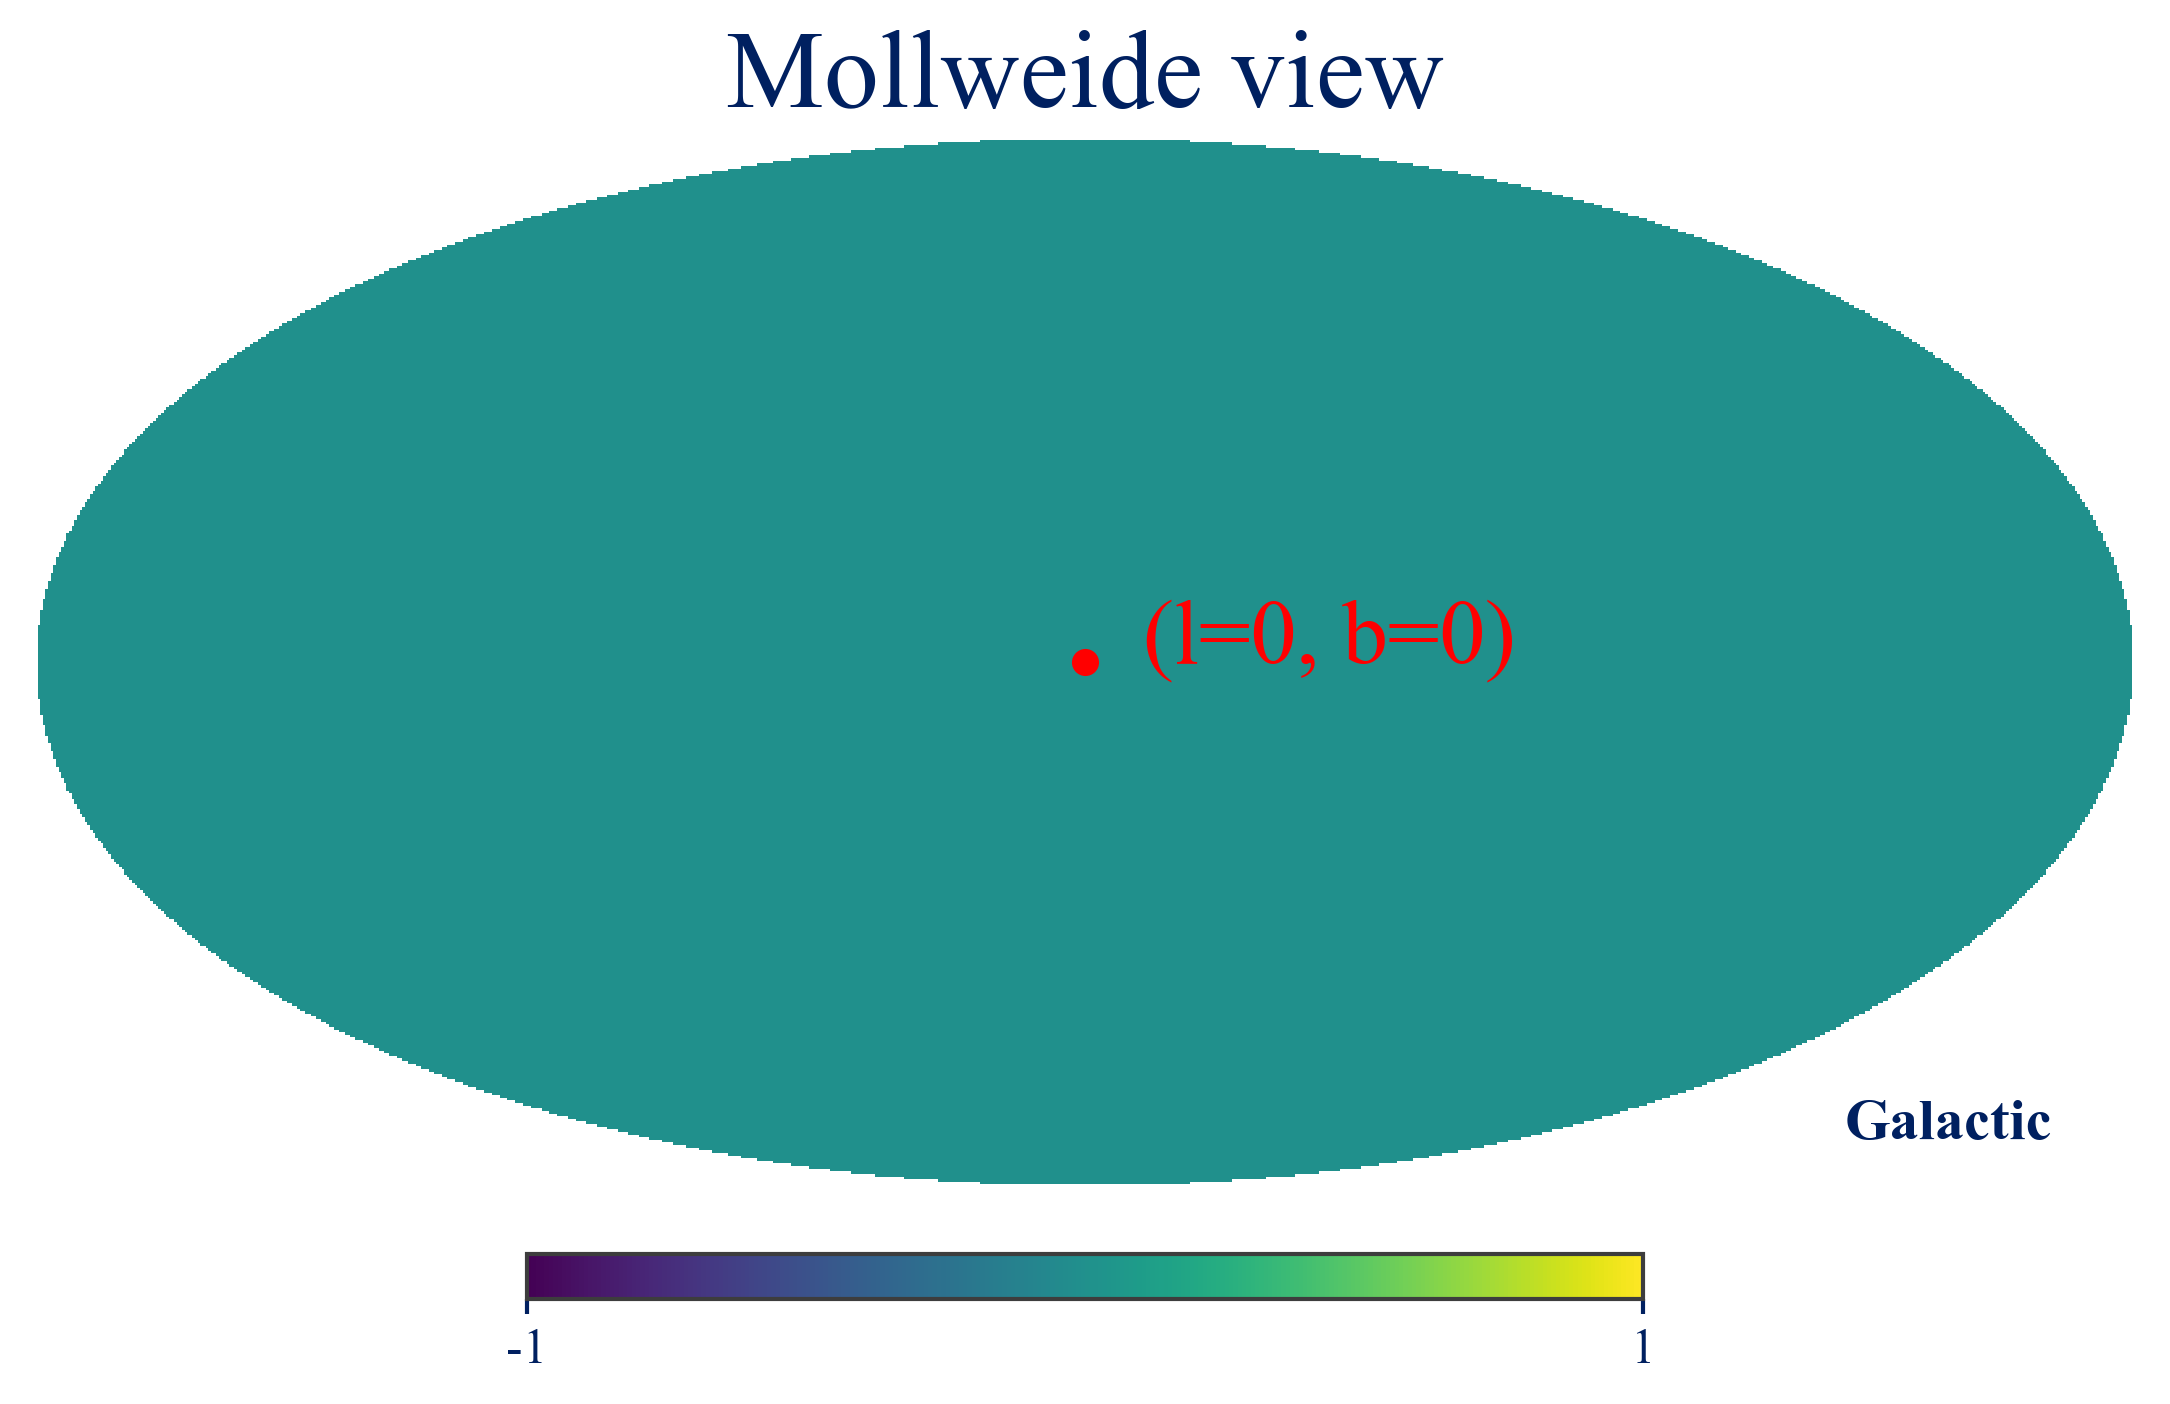

In [416]:
ts_results = ts.fit(nside = 16, spectrum = spectrum, cpu_cores=1, energy_channel=[0, 1])

hp_idx = np.argmax(ts_results)
print(ts_results.max())
print(hp_idx)

ts.plot_ts(ts_results, skycoord = None, containment = None, scheme="nested",
            save_plot = False, dpi = 300)

In [ ]:
ts = FastTSMap(
               data = data.project('Em', 'Phi', 'PsiChi'), 
               bkg_model = 0.28*new_bg,# + \
                        #    crab.binned_data.project('Em', 'Phi', 'PsiChi') + \
                        #    casa.binned_data.project('Em', 'Phi', 'PsiChi'),
               orientation = None, 
               response_path = 'psr.h5',
               cds_frame = "galactic",
               )

5161.5199089618545
1359


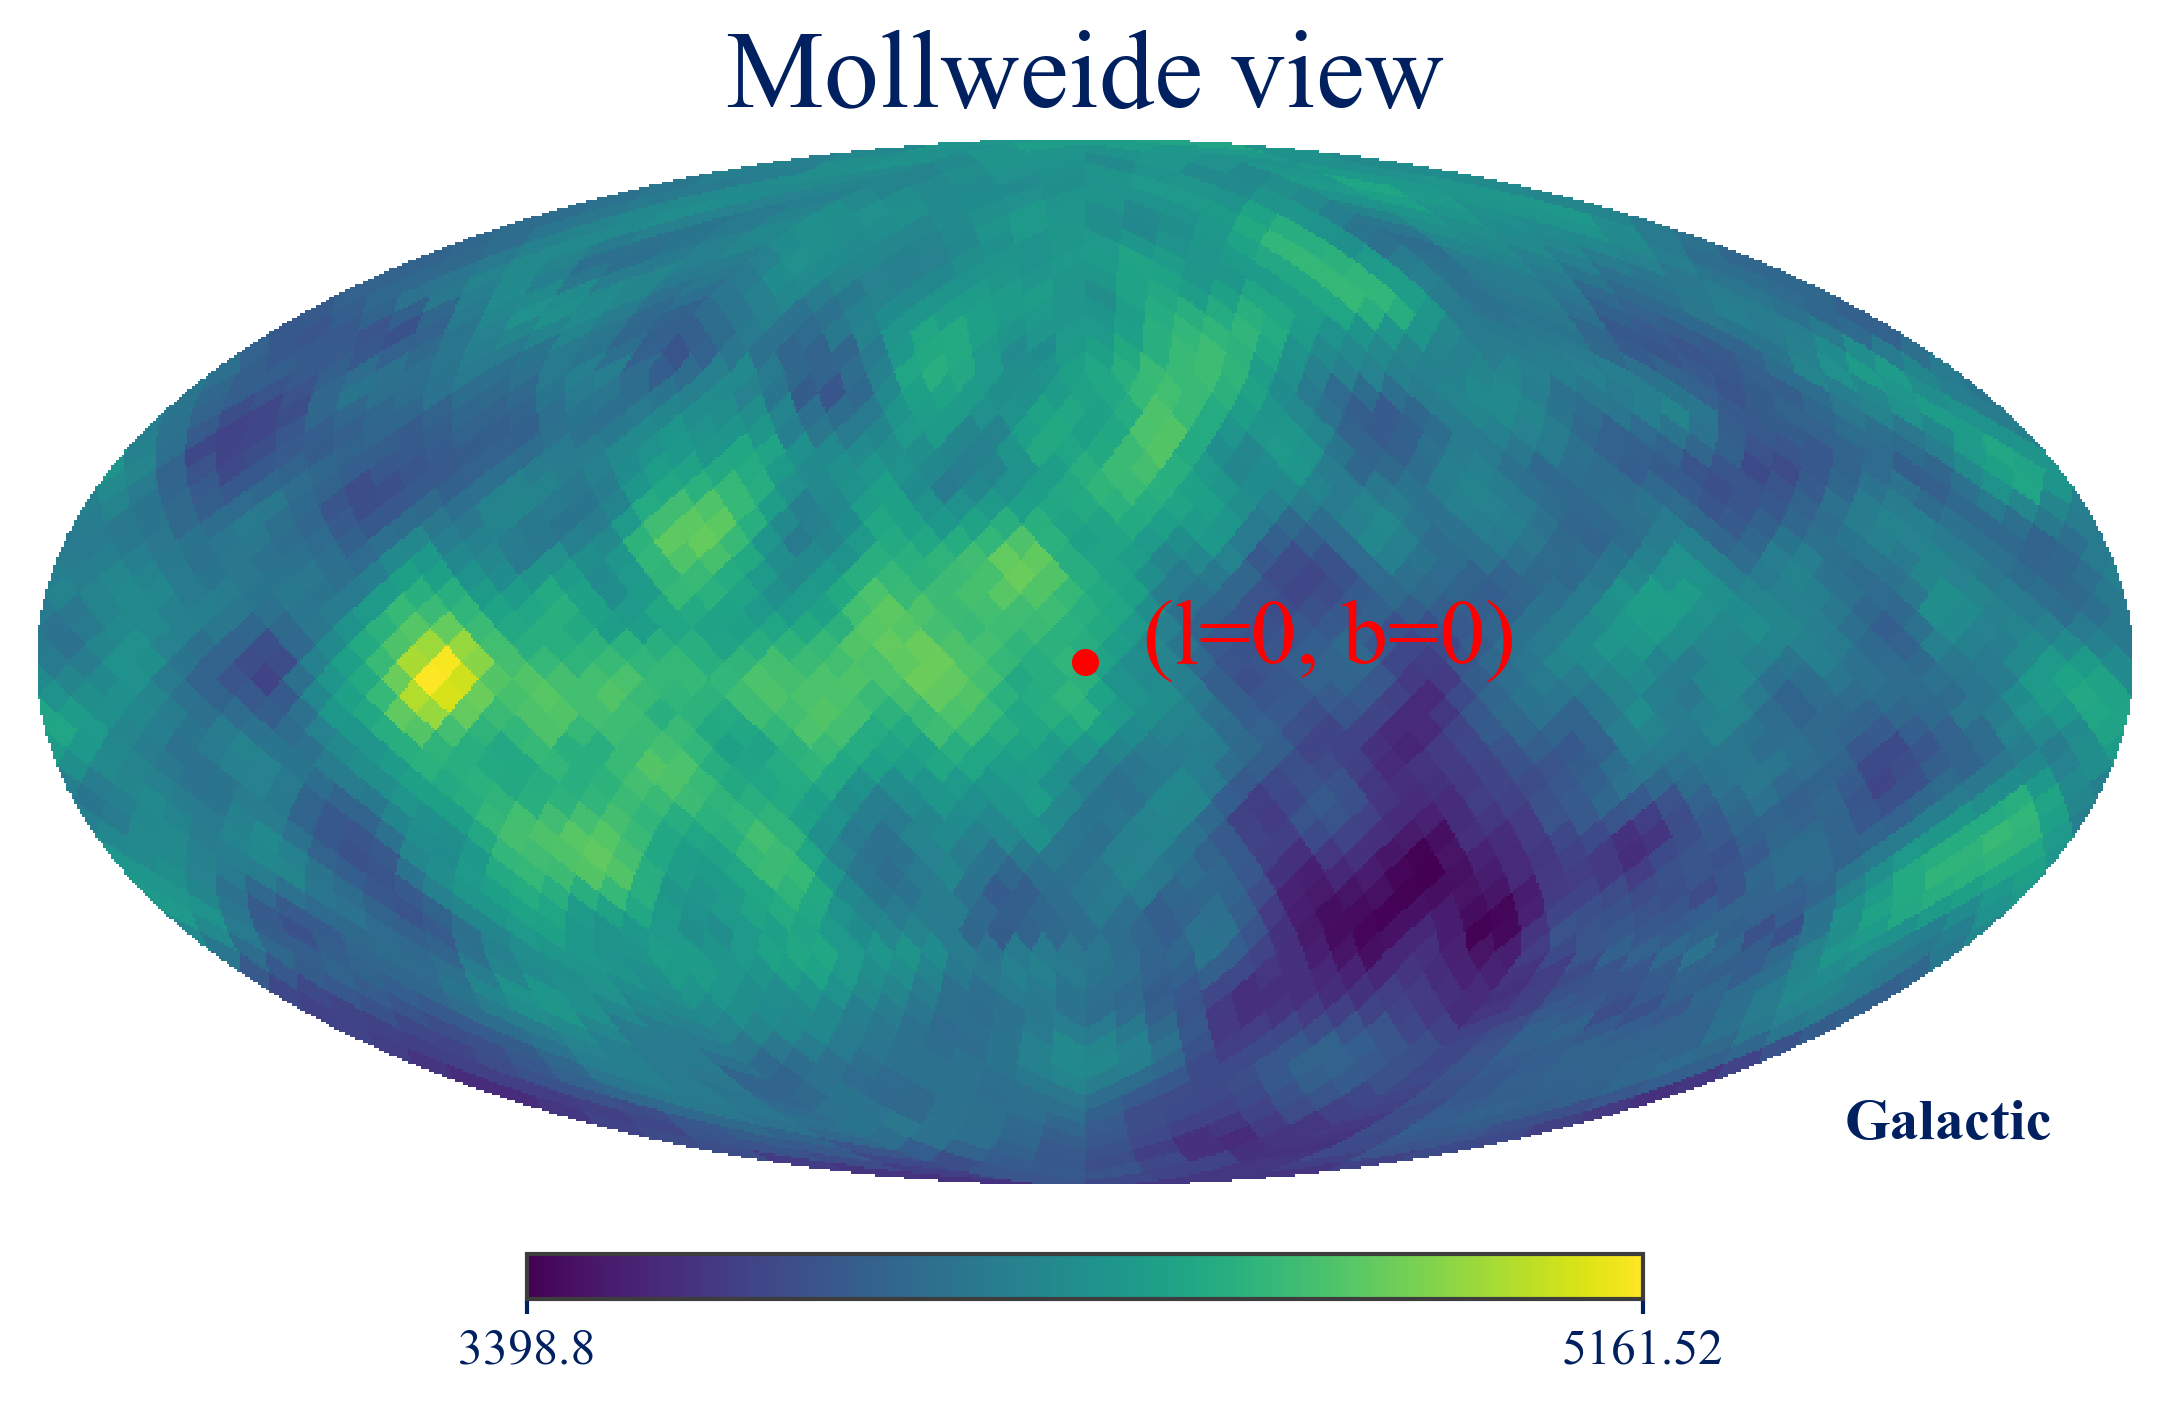

In [ ]:
ts_results = ts.fit(nside = 16, spectrum = spectrum, cpu_cores=1, energy_channel=[0, 1])

hp_idx = np.argmax(ts_results)
print(ts_results.max())
print(hp_idx)

ts.plot_ts(ts_results, skycoord = None, containment = None, scheme="nested",
            save_plot = False, dpi = 300)

In [ ]:
ts = FastTSMap(
               data = data.project('Em', 'Phi', 'PsiChi'), 
               bkg_model = 0.4*new_bg,# + \
                        #    crab.binned_data.project('Em', 'Phi', 'PsiChi') + \
                        #    casa.binned_data.project('Em', 'Phi', 'PsiChi'),
               orientation = None, 
               response_path = 'psr.h5',
               cds_frame = "galactic",
               )

506.49707217780997
1359


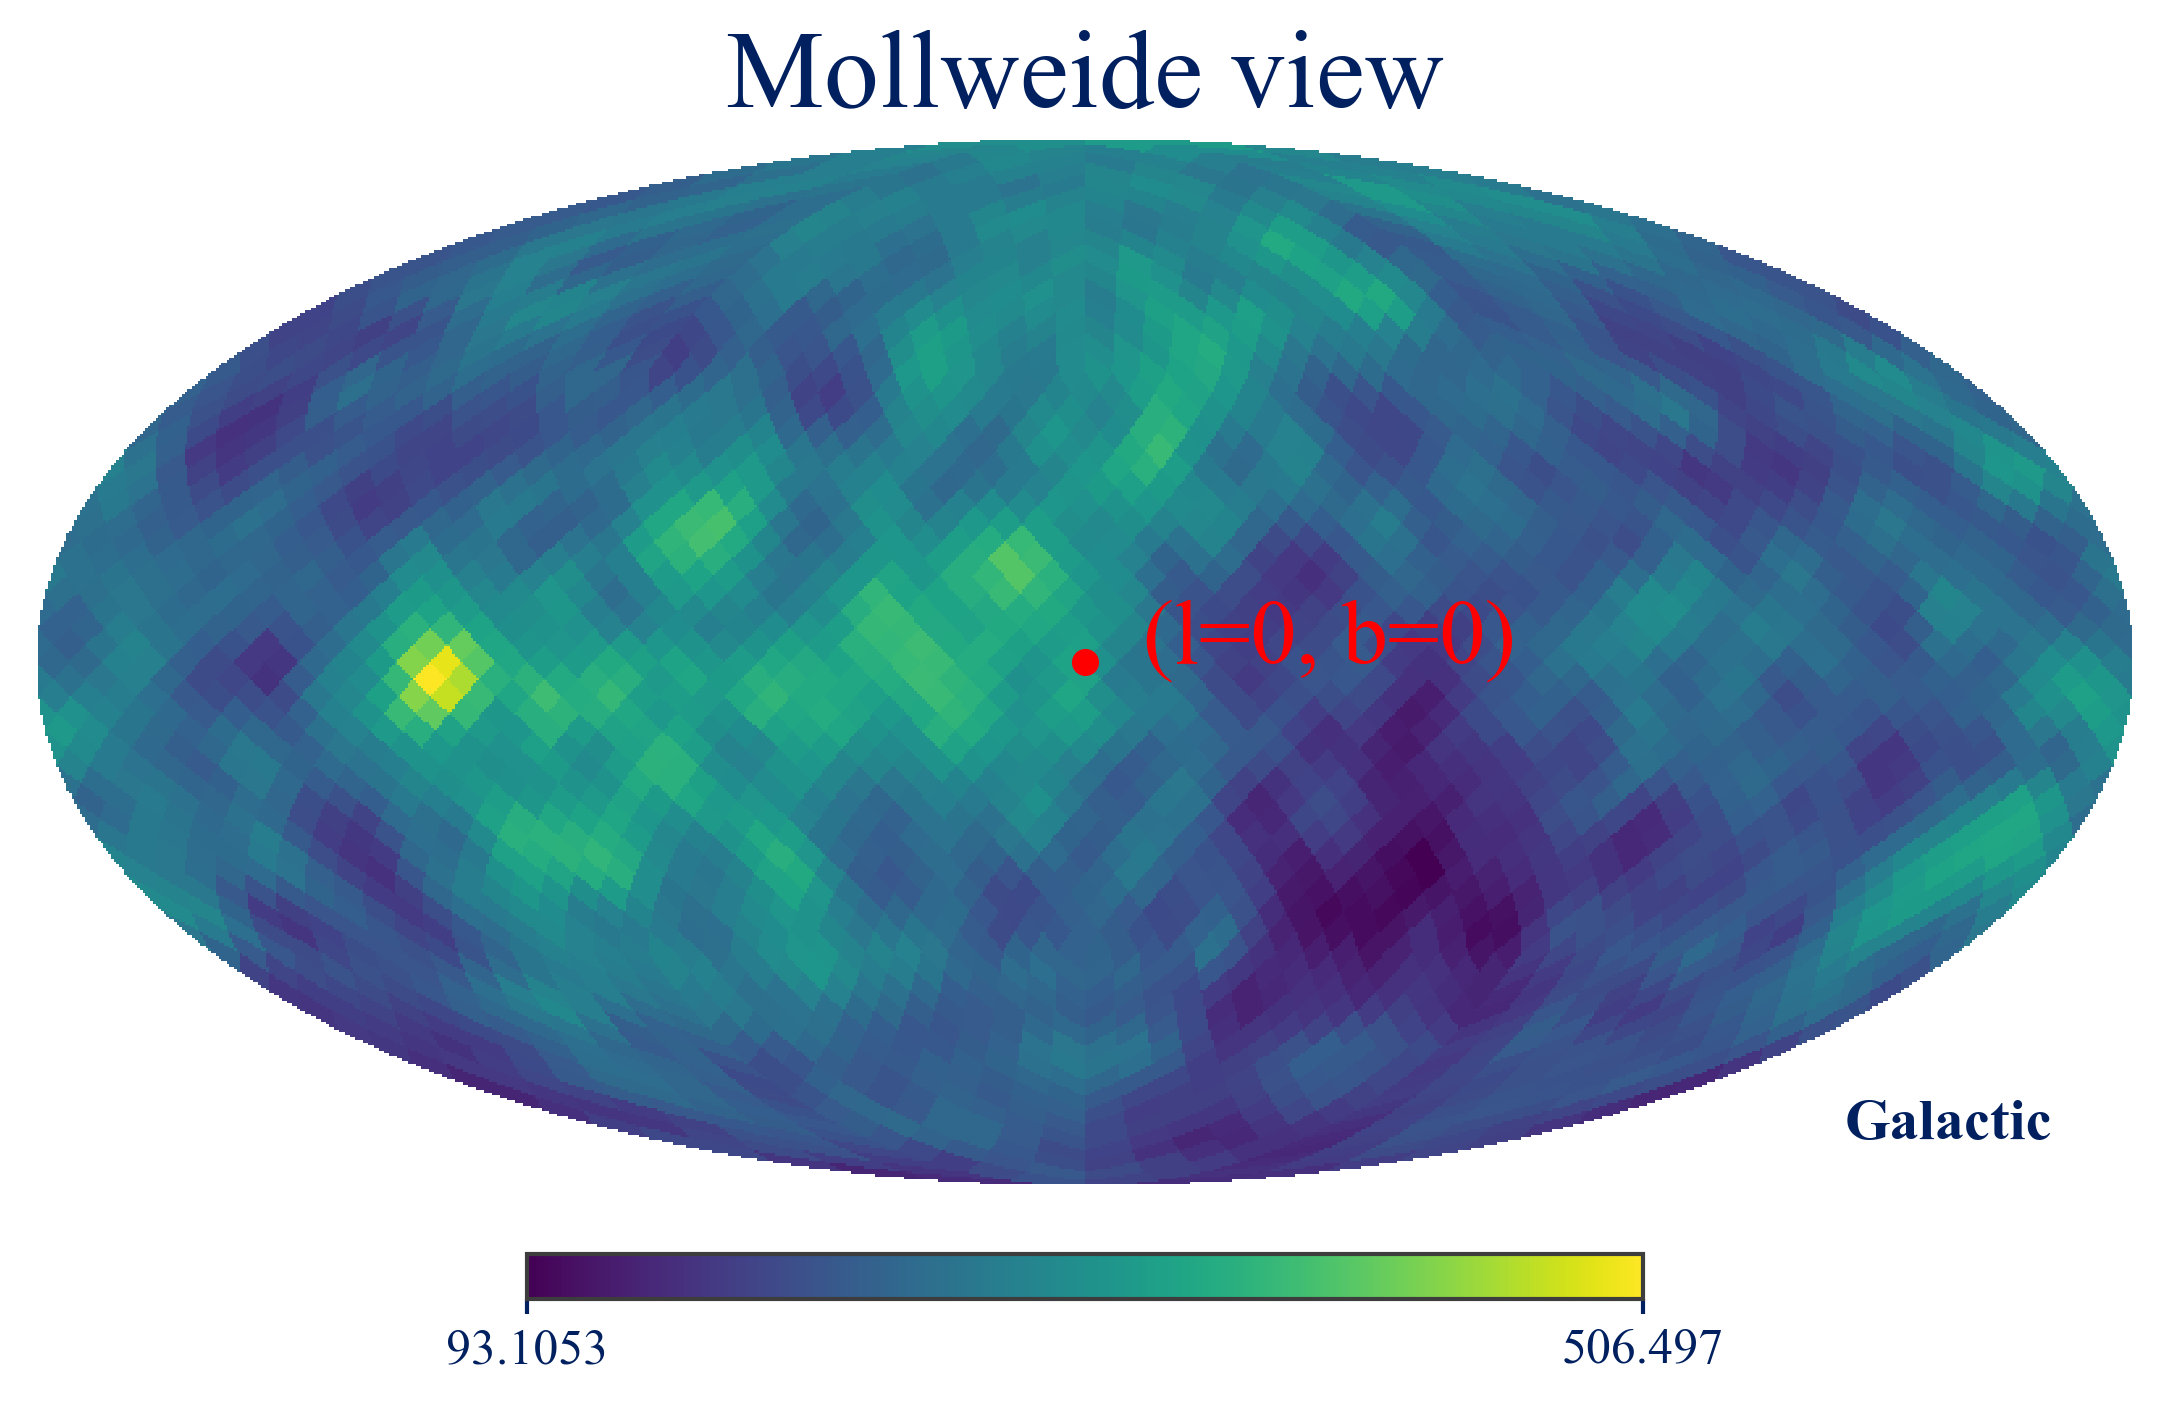

In [420]:
ts_results = ts.fit(nside = 16, spectrum = spectrum, cpu_cores=1, energy_channel=[0, 1])

hp_idx = np.argmax(ts_results)
print(ts_results.max())
print(hp_idx)

ts.plot_ts(ts_results, skycoord = None, containment = None, scheme="nested",
            save_plot = False, dpi = 300)